In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [2]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-3
MODEL_DIR  = Path("../models")
RESULT_DIR = Path("../results")

In [3]:
class_names  = np.load(MODEL_DIR / "class_names.npy", allow_pickle=True)
class_weights = np.load(MODEL_DIR / "class_weights.npy")
class_weight_dict = dict(enumerate(class_weights))
NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES}")

Number of classes: 15


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

SPLIT_DIR = Path("../data/PlantVillage_split")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode="nearest"
)
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    SPLIT_DIR / "train", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical",
    shuffle=True, seed=42
)
val_gen = val_datagen.flow_from_directory(
    SPLIT_DIR / "val", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical",
    shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    SPLIT_DIR / "test", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical",
    shuffle=False
)

Found 10777 images belonging to 15 classes.
Found 1346 images belonging to 15 classes.
Found 1351 images belonging to 15 classes.


In [12]:
def build_baseline_cnn(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation="relu",
                      padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ], name="baseline_cnn")
    return model
baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.summary()

C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,663 (2.03 MB)

 Trainable params: 529,679 (2.02 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [5]:
cb = [
    # Early stopping — stops training when val_loss stops improving
    callbacks.EarlyStopping(
        monitor="val_loss", patience=5,
        restore_best_weights=True, verbose=1
    ),
    # Reduce LR on plateau — learning rate scheduling
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    # Save best model checkpoint
    callbacks.ModelCheckpoint(
        MODEL_DIR / "baseline_cnn_best.keras",
        monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    # TensorBoard logging
    callbacks.CSVLogger(RESULT_DIR / "baseline_training_log.csv")
]


In [15]:
baseline_model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Baseline CNN compiled successfully!")

Baseline CNN compiled successfully!


In [16]:
history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=cb,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4410 - loss: 1.8752 - precision: 0.5607 - recall: 0.3374
Epoch 1: val_accuracy improved from None to 0.07504, saving model to ..\models\baseline_cnn_best.keras

Epoch 1: finished saving model to ..\models\baseline_cnn_best.keras
337/337 ━━━━━━━━━━━━━━━━━━━━ 1257s 4s/step - accuracy: 0.5420 - loss: 1.4638 - precision: 0.6525 - recall: 0.4488 - val_accuracy: 0.0750 - val_loss: 16.1974 - val_precision: 0.0751 - val_recall: 0.0750 - learning_rate: 0.0010
Epoch 2/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6804 - loss: 0.9570 - precision: 0.7571 - recall: 0.6118
Epoch 2: val_accuracy improved from 0.07504 to 0.23997, saving model to ..\models\baseline_cnn_best.keras

Epoch 2: finished saving model to ..\models\baseline_cnn_best.keras
337/337 ━━━━━━━━━━━━━━━━━━━━ 1093s 3s/step - accuracy: 0.7046 - loss: 0.8800 - precision: 0.7759 - recall: 0.6379 - val_accuracy: 0.2400 - val_loss: 7.2423 - val_precision: 0.2486 - v

KeyboardInterrupt: 

In [18]:
# Save the model state up to the completed epochs
baseline_model.save('baseline_cnn_epoch6.keras')

print("Model saved successfully! You can turn off your computer now.")

Model saved successfully! You can turn off your computer now.


In [6]:
import tensorflow as tf

#Reload your model
baseline_model = tf.keras.models.load_model('baseline_cnn_epoch6.keras')

# Resume training from Epoch 6 to your target EPOCHS (e.g., 30)
history = baseline_model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    validation_data=val_gen,
    validation_steps=len(val_gen),
    epochs=EPOCHS,                  # Total target epochs (e.g., 30)
    initial_epoch=6,                # Tells Keras to start at Epoch 7
    callbacks=cb,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 7/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8803 - loss: 0.3304 - precision: 0.9050 - recall: 0.8592
Epoch 7: val_accuracy improved from None to 0.70134, saving model to ..\models\baseline_cnn_best.keras

Epoch 7: finished saving model to ..\models\baseline_cnn_best.keras
337/337 ━━━━━━━━━━━━━━━━━━━━ 1046s 3s/step - accuracy: 0.8776 - loss: 0.3401 - precision: 0.9017 - recall: 0.8565 - val_accuracy: 0.7013 - val_loss: 1.6228 - val_precision: 0.7157 - val_recall: 0.6939 - learning_rate: 0.0010
Epoch 8/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8828 - loss: 0.3279 - precision: 0.9009 - recall: 0.8664 
Epoch 8: val_accuracy did not improve from 0.70134
337/337 ━━━━━━━━━━━━━━━━━━━━ 3849s 11s/step - accuracy: 0.8828 - loss: 0.3353 - precision: 0.9016 - recall: 0.8657 - val_accuracy: 0.5238 - val_loss: 3.7573 - val_precision: 0.5350 - val_recall: 0.5052 - learning_rate: 0.0010
Epoch 9/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8922 - loss: 0.

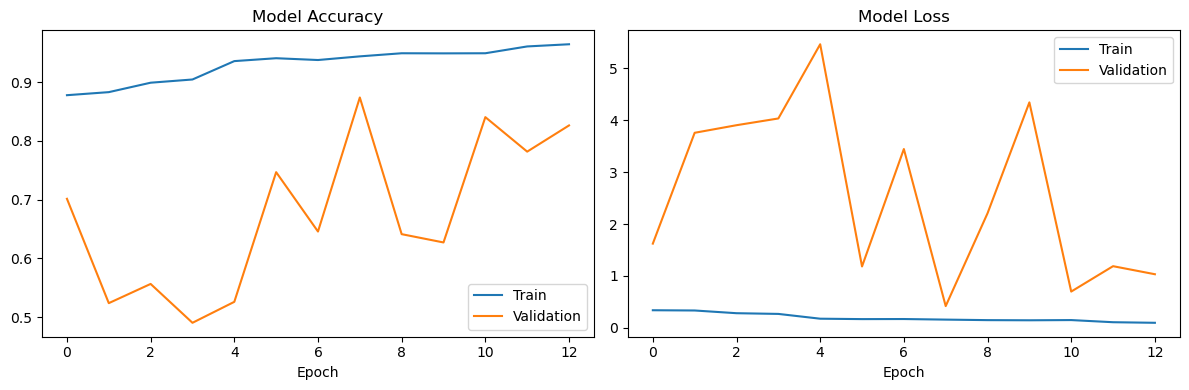

In [8]:
# Plot training curves 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/baseline_cnn_training_curves.png")
plt.show()


In [9]:
test_loss, test_accuracy, test_precision, test_recall = baseline_model.evaluate(test_gen)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8786 - loss: 0.4387 - precision: 0.8892 - recall: 0.8675
Test Accuracy : 0.8786
Test Loss     : 0.4387
Test Precision: 0.8892
Test Recall   : 0.8675


In [10]:
test_gen.reset()

pred_probs = baseline_model.predict(test_gen)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

43/43 ━━━━━━━━━━━━━━━━━━━━ 23s 514ms/step


In [11]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.87      0.98      0.92       101
                     Pepper__bell___healthy       0.82      0.99      0.90       100
                      Potato___Early_blight       0.94      0.97      0.96       100
                       Potato___Late_blight       0.81      0.85      0.83       100
                           Potato___healthy       0.41      0.88      0.56        16
                      Tomato_Bacterial_spot       0.94      0.96      0.95       100
                        Tomato_Early_blight       0.90      0.83      0.86       100
                         Tomato_Late_blight       0.94      0.73      0.82       100
                           Tomato_Leaf_Mold       0.97      0.75      0.85        96
                  Tomato_Septoria_leaf_spot       0.93      0.82      0.87       100
Tomato_Spider_mites_Two_spotted_spider_mite       0.96      0.73

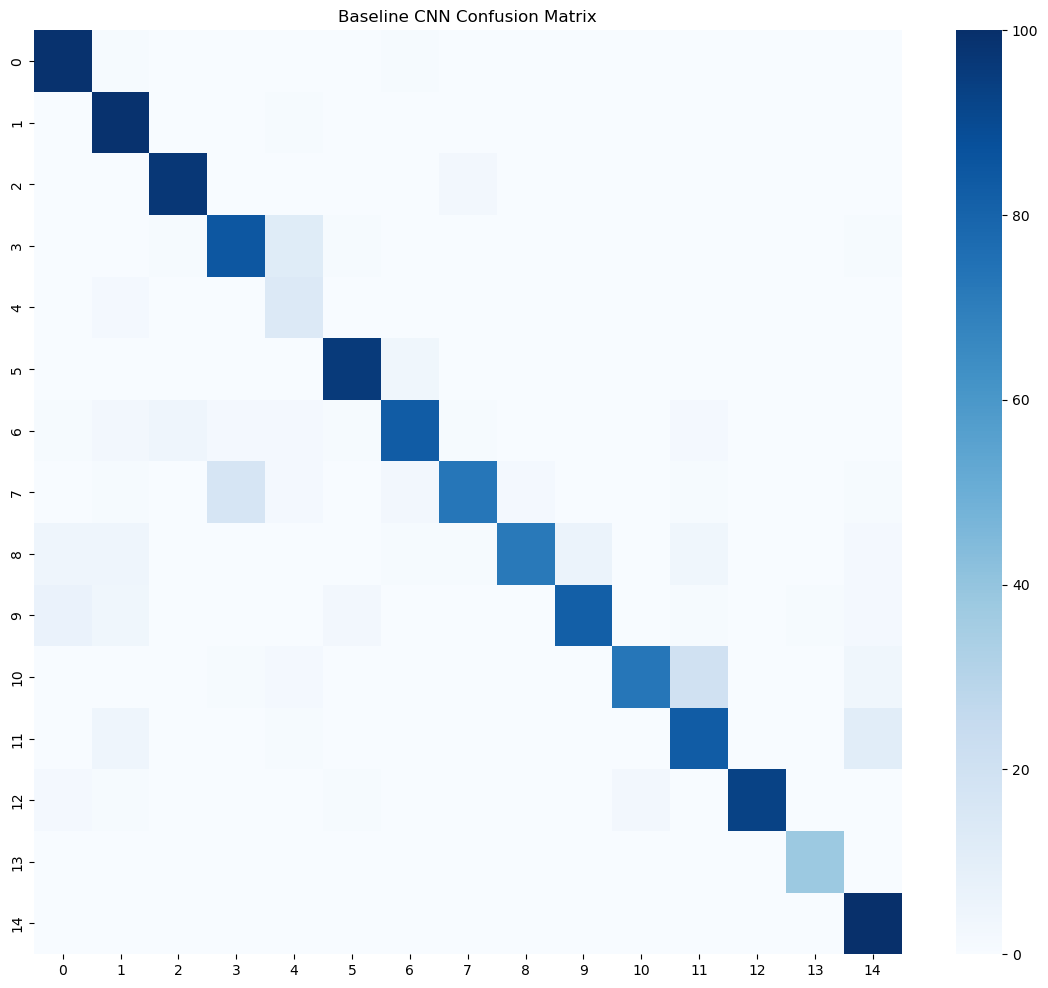

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues")
plt.title("Baseline CNN Confusion Matrix")
plt.savefig("../results/baseline_confusion_matrix.png")
plt.show()

In [13]:
baseline_model.save("../models/baseline_cnn_final.keras")

In [14]:
import json

with open("../results/baseline_history.json", "w") as f:
    json.dump(history.history, f)